In [2]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot

Paso 2: Generacion del dataset

In [10]:
X, y = make_classification(n_samples=1000, n_classes=2, random_state=1)

Paso 3: Division en entrenamiento y prueba

In [4]:
trainX, testX, trainY, testY = train_test_split(X, y, test_size=0.5, random_state=2)

Paso 4: Modelo base (sin entrenamiento)

In [5]:
ns_probs = [0 for _ in range(len(testY))]

Paso 5: Entrenamiento del modelo

In [6]:
model = LogisticRegression(solver='lbfgs')
model.fit(trainX, trainY)




LogisticRegression()

Paso 6: Prediccion de probabilidades

In [7]:
# Prediccion de probabilidades
lr_probs = model.predict_proba(testX)
#Nos quedamos con las probabilidades de la clase positiva (la probabilidad de 1)
lr_probs = lr_probs[:, 1]

Paso 7: Calculo del AUC
Se calcula el area bajo la curva

In [8]:
ns_auc = roc_auc_score(testY, ns_probs)
lr_auc = roc_auc_score(testY, lr_probs)




Resultados

In [14]:
print('Sin entrenamiento: ROC AUC=%.3f' % (ns_auc))
print('Con entrenamiento (reg logistica): ROC AUC=%.3f' % (lr_auc))


Sin entrenamiento: ROC AUC=0.500
Con entrenamiento (reg logistica): ROC AUC=0.944


Paso 8: Curvas ROC
Calculamos las tasas de verdaderos y falsos positivos

In [16]:
ns_fpr, ns_tpr, _ = roc_curve(testY, ns_probs)
lr_fpr, lr_tpr, _ = roc_curve(testY, lr_probs)


Paso 9: Graficacion

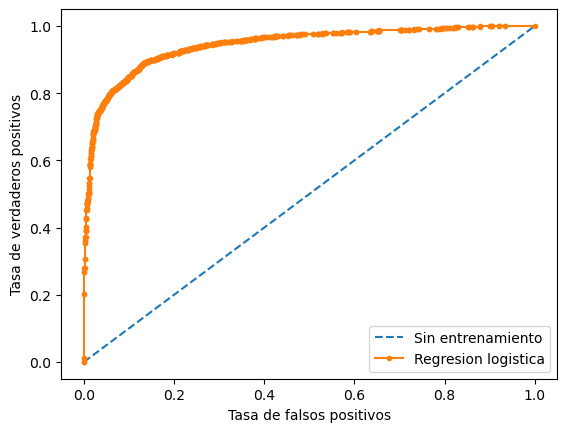

In [17]:
pyplot.plot(ns_fpr, ns_tpr, linestyle='--', label='Sin entrenamiento')
pyplot.plot(lr_fpr, lr_tpr, marker='.', label='Regresion logistica')
pyplot.xlabel('Tasa de falsos positivos')
pyplot.ylabel('Tasa de verdaderos positivos')
pyplot.legend()
pyplot.show()